# Quantum Hackathon Notebook

This notebook is organized into three parts:
1. Optimization / lifetime estimation
2. Drifted Hamiltonians
3. Static Hamiltonians

All drift and static examples below use the `+x` initial state and display both the expectation-value plot and the Wigner function, together with the Hamiltonian used.

In [19]:
import sys
from pathlib import Path

from IPython.display import display, Markdown, Image
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd() / "src"))

import jax.numpy as jnp

import plot_expectation_value as PlotExp
import Wigner_representation as Wrep
import static_hamiltonians as statH
import drift_hamiltonians as driftH

## 1. Optimization / lifetime estimation

Optimization Team, do your thing


In [20]:
# Auto-reload modules when they change
%load_ext autoreload
%autoreload 2

### Cat Qubit Optimization

Online CMA-ES optimization for dissipative cat qubit stabilization.
Connects `models.py` → `Model_to_halflife.py` → `cmaes`.

In [21]:
# ============================================================
# CONFIGURATION
# ============================================================
MODEL = "standard_cat"        # standard_cat, moon_cat, kerr_cat, drift_compensated_cat, effective_cat
DRIFT = "none"                # none, amplitude, frequency, both
N_EPOCHS = 30
BATCH_SIZE = 12
TARGET_BIAS = 500.0
LAMBDA_PENALTY = 0.001
SEED = 32
OBJECTIVE = "log_sum_penalty"   # see objectives.py for options
OBJECTIVE_KWARGS = {}           # extra kwargs for the objective

In [22]:
import sys, os, time
sys.path.insert(0, "src")
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["JAX_PLATFORMS"] = "cpu"
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from IPython.display import display
from concurrent.futures import ThreadPoolExecutor, as_completed
from cmaes import SepCMA
from objectives import OBJECTIVES
from optimizer import run_optimization
from models import MODELS, NA, NB, compute_alpha
from Model_to_halflife import measure_lifetime
from drift_hamiltonians import FULL_HAMILTONIANS_WITH_DRIFT

In [23]:
print(f"Model: {MODEL}")
print(f"Drift: {DRIFT}")
print(f"Target bias: η={TARGET_BIAS}")

Model: standard_cat
Drift: none
Target bias: η=500.0


In [24]:
print('Running optimization...')
history = run_optimization(
    model_name=MODEL,
    drift_type=DRIFT,
    target_bias=TARGET_BIAS,
    lambda_penalty=LAMBDA_PENALTY,
    batch_size=BATCH_SIZE,
    n_epochs=N_EPOCHS,
    seed=SEED,
    objective=OBJECTIVE,
    objective_kwargs=OBJECTIVE_KWARGS,
)


Running optimization...


/home/user/miniconda3/envs/qhack26/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIAQArray` has been converted to a `DenseQArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)


Epoch   0/30 | reward=-63.494 | T_Z=67.7 | T_X=0.169 | η=401 | [4s]
Epoch   3/30 | reward=-18.126 | T_Z=75.2 | T_X=0.145 | η=518 | [14s]
Epoch   6/30 | reward=-0.088 | T_Z=72.1 | T_X=0.141 | η=510 | [23s]
Epoch   9/30 | reward=1.704 | T_Z=77.4 | T_X=0.154 | η=504 | [33s]
Epoch  12/30 | reward=1.491 | T_Z=74.8 | T_X=0.150 | η=499 | [42s]
Epoch  15/30 | reward=2.393 | T_Z=77.5 | T_X=0.155 | η=500 | [52s]
Epoch  18/30 | reward=2.434 | T_Z=79.6 | T_X=0.160 | η=497 | [61s]
Epoch  21/30 | reward=2.430 | T_Z=81.4 | T_X=0.163 | η=500 | [71s]
Epoch  24/30 | reward=2.309 | T_Z=82.0 | T_X=0.165 | η=498 | [80s]
Epoch  27/30 | reward=2.453 | T_Z=83.4 | T_X=0.167 | η=499 | [90s]
Epoch  29/30 | reward=2.407 | T_Z=82.8 | T_X=0.165 | η=502 | [97s]

Done. Final: T_Z=82.8, T_X=0.165, η=502
Params: ['1.1664', '0.1913', '4.6870', '-0.1030']


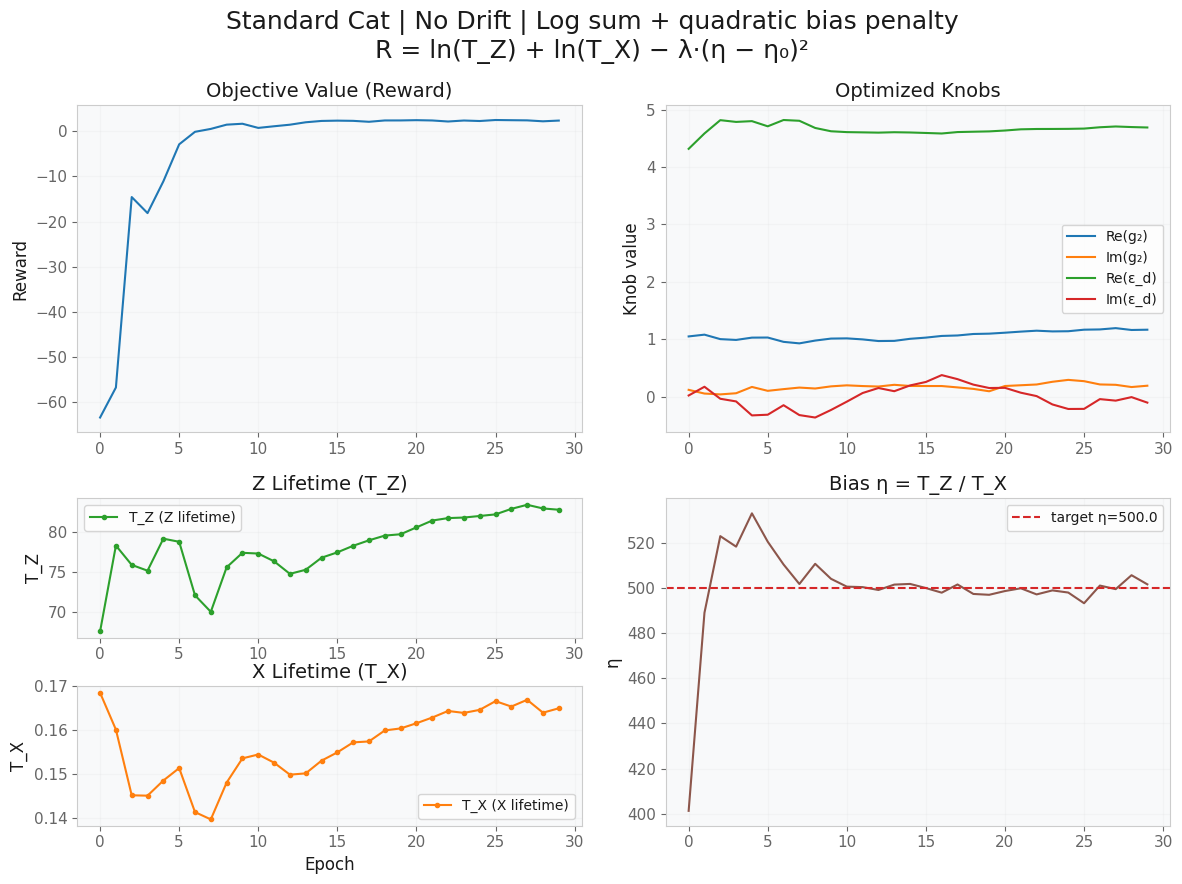

Final: T_Z=82.8, T_X=0.1650, η=502


In [25]:
DARK_MODE = False

if DARK_MODE:
    BG = '#1a1a1a'
    FG = '#cccccc'
    GRID = '#333333'
    FIG_BG = '#111111'
    SPINE = '#444444'
    TICK = '#888888'
    LEGEND_BG = '#222222'
else:
    BG = '#f8f9fa'
    FG = '#1a1a1a'
    GRID = '#dddddd'
    FIG_BG = '#ffffff'
    SPINE = '#cccccc'
    TICK = '#666666'
    LEGEND_BG = '#ffffff'

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'text.color': FG,
    'axes.facecolor': BG,
    'axes.edgecolor': SPINE,
    'axes.labelcolor': FG,
    'axes.titlecolor': FG,
    'xtick.color': TICK,
    'ytick.color': TICK,
    'legend.facecolor': LEGEND_BG,
    'legend.edgecolor': SPINE,
    'legend.labelcolor': FG,
    'grid.color': GRID,
    'figure.facecolor': FIG_BG,
})

e = np.arange(len(history["reward"]))
fig = plt.figure(figsize=(12, 9))
gs = fig.add_gridspec(2, 2)
fig.suptitle(
    f"{MODELS[MODEL]['label']} | {FULL_HAMILTONIANS_WITH_DRIFT[DRIFT]['label']} | "
    f"{OBJECTIVES[OBJECTIVE]['label']}\n"
    f"{OBJECTIVES[OBJECTIVE]['eq']}",
    fontsize=18, color=FG
)

ax_reward = fig.add_subplot(gs[0, 0])
ax_knobs = fig.add_subplot(gs[0, 1])

gs_life = gs[1, 0].subgridspec(2, 1, hspace=0.35)
ax_tz = fig.add_subplot(gs_life[0])
ax_tx = fig.add_subplot(gs_life[1])

ax_eta = fig.add_subplot(gs[1, 1])

knob_col = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854', '#ffd92f']
if not DARK_MODE:
    knob_col = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

ax_reward.plot(e, history["reward"], color=knob_col[0])
ax_reward.set_title("Objective Value (Reward)")
ax_reward.set_ylabel("Reward")
ax_reward.grid(True, alpha=0.2)
ax_reward.set_facecolor(BG)

mp = np.array(history["mean_params"])
for i in range(mp.shape[1]):
    ax_knobs.plot(e, mp[:, i], label=MODELS[MODEL]["knob_names"][i], color=knob_col[i % len(knob_col)])
ax_knobs.set_title("Optimized Knobs")
ax_knobs.set_ylabel("Knob value")
ax_knobs.legend(fontsize=10)
ax_knobs.grid(True, alpha=0.2)
ax_knobs.set_facecolor(BG)

ax_tz.plot(e, history["tz"], "o-", markersize=3, color=knob_col[2], label="T_Z (Z lifetime)")
ax_tz.set_title("Z Lifetime (T_Z)")
ax_tz.set_ylabel("T_Z")
ax_tz.legend(fontsize=10)
ax_tz.grid(True, alpha=0.2)
ax_tz.set_facecolor(BG)

ax_tx.plot(e, history["tx"], "o-", color=knob_col[1], markersize=3, label="T_X (X lifetime)")
ax_tx.set_title("X Lifetime (T_X)")
ax_tx.set_ylabel("T_X")
ax_tx.set_xlabel("Epoch")
ax_tx.legend(fontsize=10)
ax_tx.grid(True, alpha=0.2)
ax_tx.set_facecolor(BG)

ax_eta.plot(e, history["eta"], color=knob_col[5])
ax_eta.axhline(TARGET_BIAS, color=knob_col[3], ls="--", label=f"target η={TARGET_BIAS}")
ax_eta.set_title("Bias η = T_Z / T_X")
ax_eta.set_ylabel("η")
ax_eta.legend(fontsize=10)
ax_eta.grid(True, alpha=0.2)
ax_eta.set_facecolor(BG)

plt.tight_layout()
plt.show()

tz_last = history["tz"][-1]
tx_last = history["tx"][-1]
print(f"Final: T_Z={tz_last:.1f}, T_X={tx_last:.4f}, η={tz_last / tx_last:.0f}")

## 2. Drifting Hamiltonians

Each drift case shows two blocks: one for the `+x` initial state and one for the `+z` initial state. Each block displays the expectation-value plot and the Wigner GIF (no files are saved).

### Amplitude drift - +x state

Hamiltonian:

$H = g_2^* a^{\dagger 2} b + g_2 a^2 b^\dagger - \epsilon_d(t) b^\dagger - \epsilon_d^*(t) b$, with $\epsilon_d(t) = \epsilon_0 e^{\gamma t}$ as in `build_amplitude_drift`.

/home/user/miniconda3/envs/qhack26/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIAQArray` has been converted to a `DenseQArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/user/projects/QHack26/Iason/src/Wigner_function_plotting.py:125: ComplexWarning: Casting complex values to real discards the imaginary part
  values = np.asarray(wigner_data, dtype=float)


Wigner GIF created: wigner.gif


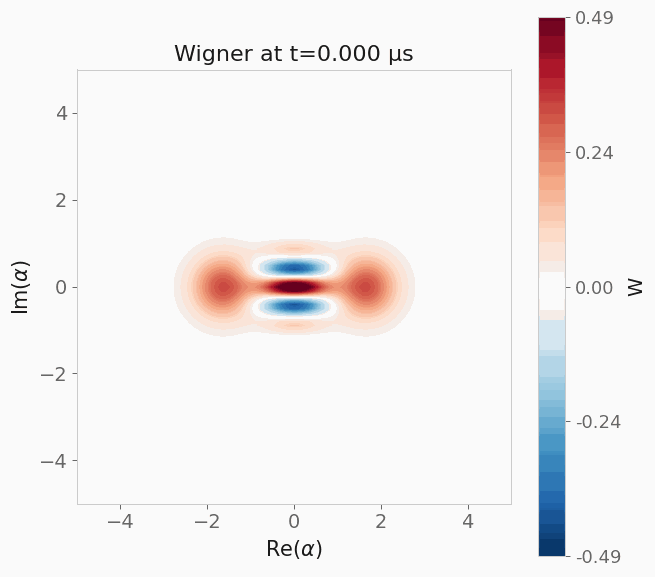

Amplitude drift (+x) lifetime: 0.1785


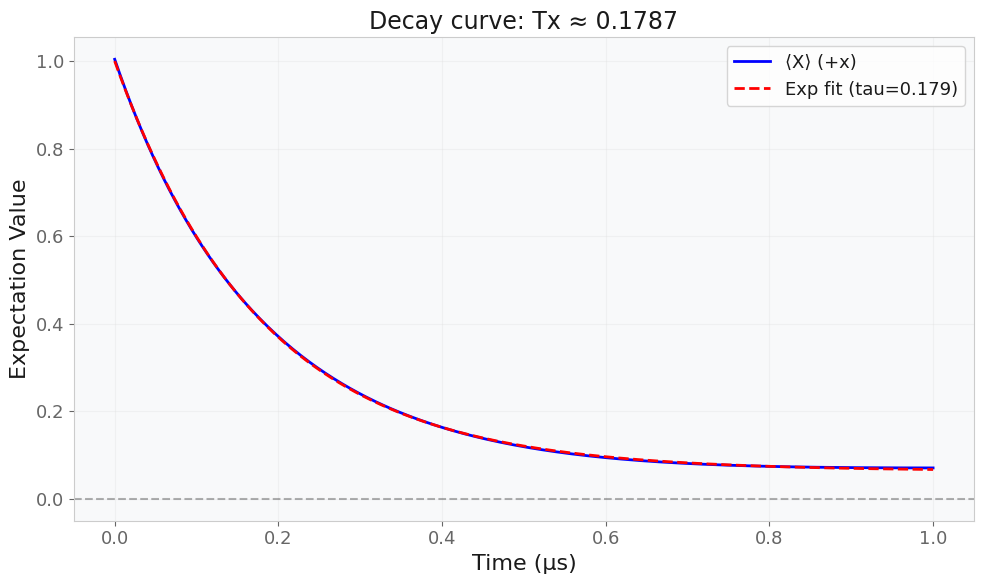

In [26]:
amp_data_x = {
    "initial_state": "+x",
    "Hilbert_space_large": 18,
    "Hilbert_space_cutted_for_solution": 6,
    "knobs": [1.0, 0.0, 4.0, 0.0],
    "kappa_a": 1.0,
    "kappa_b": 10.0,
    # tfinal will be assigned below based on initial_state to match generators
}
H = driftH.build_amplitude_drift(amp_data_x)
amp_data_x["Hamiltonian"] = H
# choose tfinal consistent with generator scripts
tfinal = 200.0 if amp_data_x["initial_state"] == "+z" else 1.0
amp_data_x["tfinal"] = tfinal
halflife, plot_path, _ = PlotExp.plot_expectation_value(amp_data_x)
wigner_path = Wrep.show_wigner_evolution(amp_data_x)
print(f"Amplitude drift (+x) lifetime: {halflife:.4f}")

### Amplitude drift - +z state

/home/user/projects/QHack26/Iason/src/Wigner_function_plotting.py:125: ComplexWarning: Casting complex values to real discards the imaginary part
  values = np.asarray(wigner_data, dtype=float)


Wigner GIF created: wigner.gif


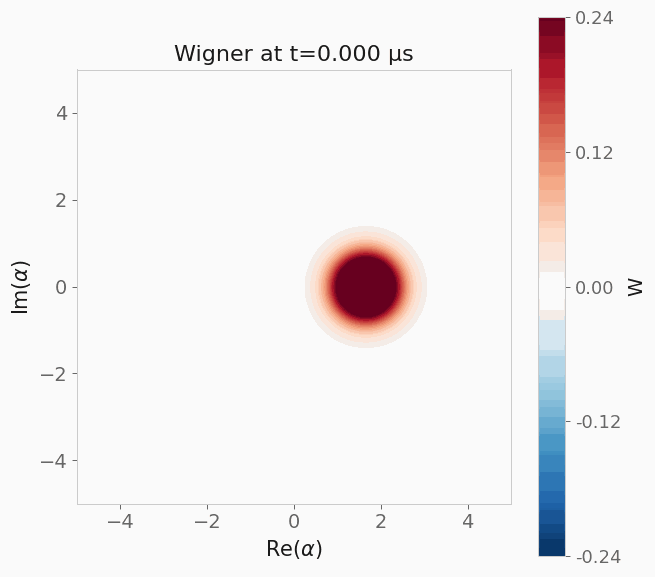

Amplitude drift (+z) lifetime: 57.3575


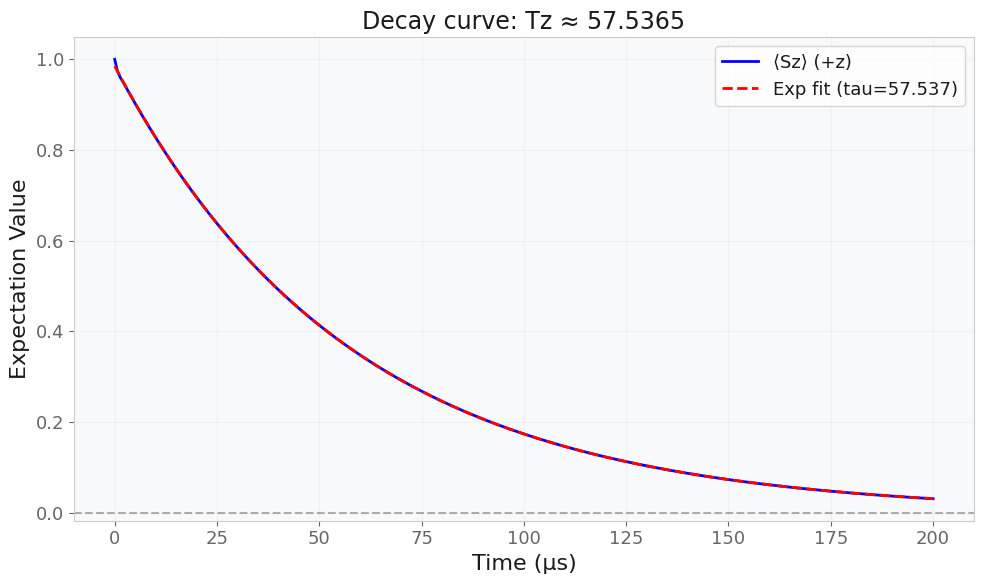

In [27]:
amp_data_z = {
    "initial_state": "+z",
    "Hilbert_space_large": 18,
    "Hilbert_space_cutted_for_solution": 6,
    "knobs": [1.0, 0.0, 4.0, 0.0],
    "kappa_a": 1.0,
    "kappa_b": 10.0,
    # tfinal will be assigned below based on initial_state to match generators
}
H = driftH.build_amplitude_drift(amp_data_z)
amp_data_z["Hamiltonian"] = H
# choose tfinal consistent with generator scripts
tfinal = 200.0 if amp_data_z["initial_state"] == "+z" else 1.0
amp_data_z["tfinal"] = tfinal
halflife, plot_path, _ = PlotExp.plot_expectation_value(amp_data_z)
wigner_path = Wrep.show_wigner_evolution(amp_data_z)
print(f"Amplitude drift (+z) lifetime: {halflife:.4f}")

### Frequency drift - +x state

Hamiltonian:

$H = g_2^* a^{\dagger 2} b + g_2 a^2 b^\dagger - \epsilon_d b^\dagger - \epsilon_d^* b + \Delta(t) a^\dagger a$, with $\Delta(t) = A \sin(\omega t + \phi)$ as written in `build_frequency_drift`.

/home/user/miniconda3/envs/qhack26/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIAQArray` has been converted to a `DenseQArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/user/miniconda3/envs/qhack26/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIAQArray` has been converted to a `DenseQArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/user/projects/QHack26/Iason/src/Wigner_function_plotting.py:125: ComplexWarning: Casting complex values to real discards the imaginary part
  values = np.asarray(wigner_data, dtype=float)


Wigner GIF created: wigner.gif


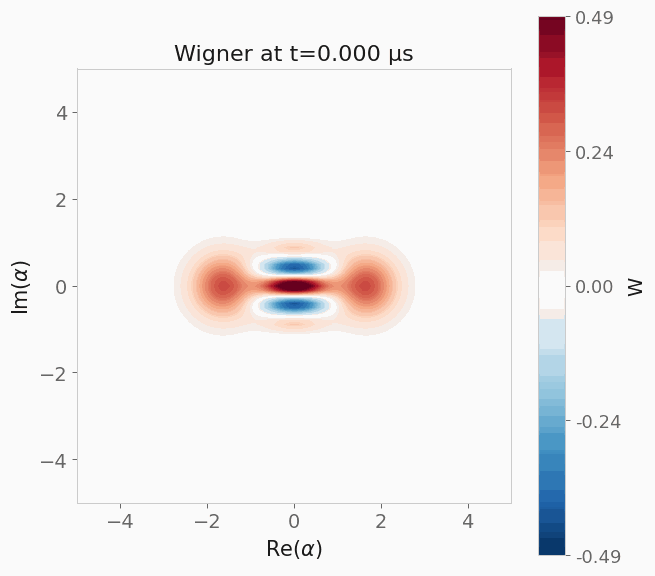

Frequency drift (+x) lifetime: 0.1786


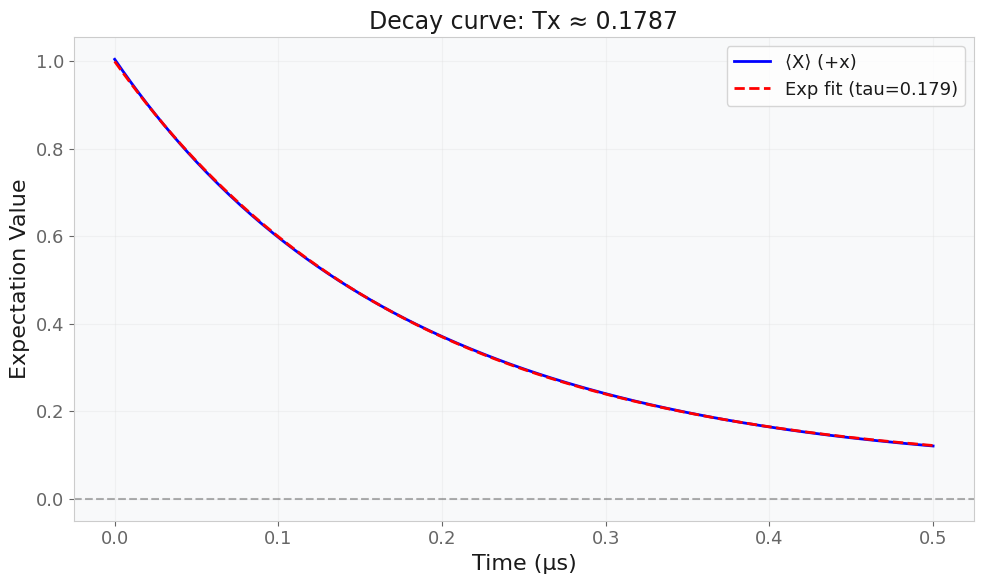

In [28]:
freq_data_x = {
    "initial_state": "+x",
    "Hilbert_space_large": 16,
    "Hilbert_space_cutted_for_solution": 5,
    "knobs": [1.0, 0.0, 4.0, 0.0],
    "kappa_a": 1.0,
    "kappa_b": 10.0,
    # tfinal will be assigned below based on initial_state to match generators
    "drift_params": [0.5, 5.0 * jnp.pi, 0.0],
}
H = driftH.build_frequency_drift(freq_data_x)
freq_data_x["Hamiltonian"] = H
# choose tfinal consistent with generator scripts
tfinal = 200.0 if freq_data_x["initial_state"] == "+z" else 0.5
freq_data_x["tfinal"] = tfinal
halflife, plot_path, _ = PlotExp.plot_expectation_value(freq_data_x)
wigner_path = Wrep.show_wigner_evolution(freq_data_x)
print(f"Frequency drift (+x) lifetime: {halflife:.4f}")

### Frequency drift - +z state

Hamiltonian:

$H = g_2^* a^{\dagger 2} b + g_2 a^2 b^\dagger - \epsilon_d b^\dagger - \epsilon_d^* b + \Delta(t) a^\dagger a$, with $\Delta(t) = A \sin(\omega t + \phi)$ as written in `build_frequency_drift`.

/home/user/projects/QHack26/Iason/src/Wigner_function_plotting.py:125: ComplexWarning: Casting complex values to real discards the imaginary part
  values = np.asarray(wigner_data, dtype=float)


Wigner GIF created: wigner.gif


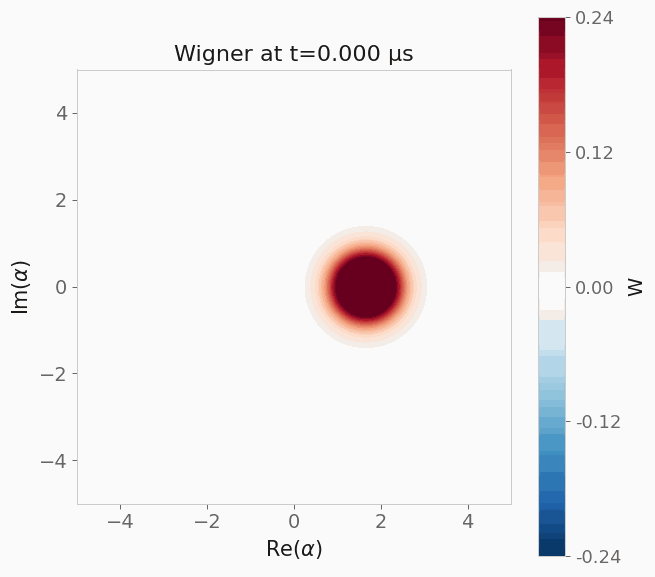

Frequency drift (+z) lifetime: 46.1156


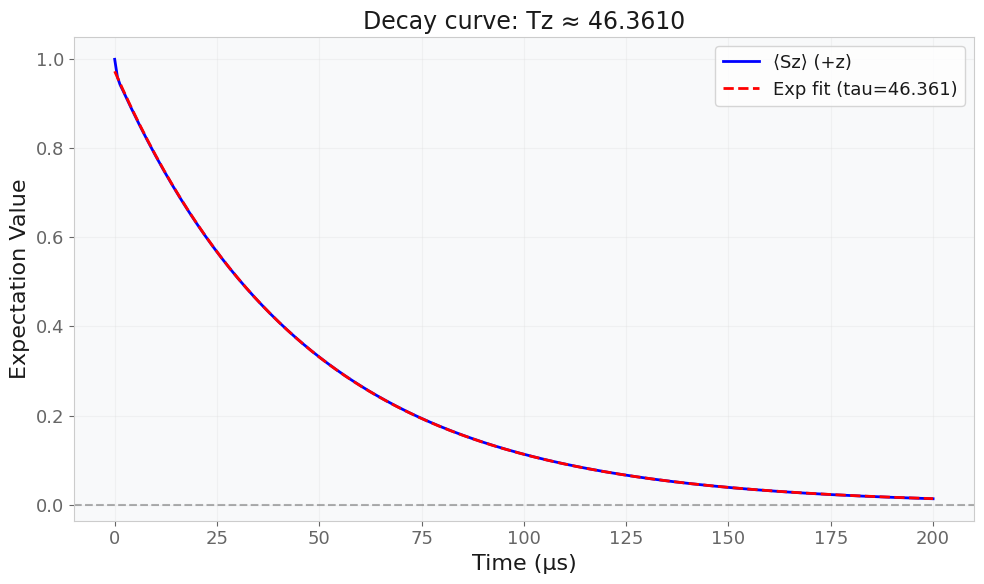

In [29]:
freq_data_z = {
    "initial_state": "+z",
    "Hilbert_space_large": 16,
    "Hilbert_space_cutted_for_solution": 5,
    "knobs": [1.0, 0.0, 4.0, 0.0],
    "kappa_a": 1.0,
    "kappa_b": 10.0,
    # tfinal will be assigned below based on initial_state to match generators
    "drift_params": [0.2, 2.0 * jnp.pi, 0.0],
}
H = driftH.build_frequency_drift(freq_data_z)
freq_data_z["Hamiltonian"] = H
# choose tfinal consistent with generator scripts
tfinal = 200.0 if freq_data_z["initial_state"] == "+z" else 1.0
freq_data_z["tfinal"] = tfinal
halflife, plot_path, _ = PlotExp.plot_expectation_value(freq_data_z)
wigner_path = Wrep.show_wigner_evolution(freq_data_z)
print(f"Frequency drift (+z) lifetime: {halflife:.4f}")

### TLS drift - +x state

Hamiltonian:

$H = g_2^* a^{\dagger 2} b + g_2 a^2 b^\dagger - \epsilon_d b^\dagger - \epsilon_d^* b + g_{\rm tls}(t) (a\sigma_+ + a^\dagger\sigma_-)$, with $g_{\rm tls}(t) = A \sin(\omega t + \phi)$ as written in `build_tls_drift`.

In [49]:
def run_tls_drift_lifetime(data, driftH, nsteps=100):
    import numpy as np
    import jax.numpy as jnp
    import dynamiqs as dq
    import matplotlib.pyplot as plt
    from pathlib import Path
    from postprocess import robust_exp_fit

    data = dict(data)
    init = data["initial_state"]
    data["tfinal"] = data.get("tfinal", 200.0 if init in ["+z", "-z"] else 1.0)

    H = data.get("Hamiltonian", driftH.build_tls_drift(data))

    na = data["Hilbert_space_large"]
    nb = data["Hilbert_space_cutted_for_solution"]
    ntls = data.get("tls_dim", 2)

    a = dq.tensor(dq.destroy(na), dq.eye(nb), dq.eye(ntls))
    b = dq.tensor(dq.eye(na), dq.destroy(nb), dq.eye(ntls))

    losses = [
        jnp.sqrt(data["kappa_b"]) * b,
        jnp.sqrt(data["kappa_a"]) * a,
    ]

    g2 = data["knobs"][0] + 1j * data["knobs"][1]
    eps_d = data["knobs"][2] + 1j * data["knobs"][3]
    eps_2 = 2 * g2 * eps_d / data["kappa_b"]
    kappa_2 = 4 * jnp.abs(g2) ** 2 / data["kappa_b"]
    alpha = jnp.sqrt(2 / kappa_2 * (eps_2 - data["kappa_a"] / 4))

    ket_p = dq.coherent(na, alpha)
    ket_m = dq.coherent(na, -alpha)

    basis = {
        "+z": ket_p,
        "-z": ket_m,
        "+x": (ket_p + ket_m) / jnp.sqrt(2),
        "-x": (ket_p - ket_m) / jnp.sqrt(2),
    }

    psi0 = dq.tensor(basis[init], dq.fock(nb, 0), dq.fock(ntls, 0))

    if init in ["+x", "-x"]:
        observable = (1j * jnp.pi * a.dag() @ a).expm()
        obs_label = "⟨X⟩"
    else:
        z_storage = ket_p @ ket_p.dag() - ket_m @ ket_m.dag()
        observable = dq.tensor(z_storage, dq.eye(nb), dq.eye(ntls))
        obs_label = "⟨Z⟩"

    tsave = jnp.linspace(0, data["tfinal"], nsteps)

    res = dq.mesolve(
        H,
        losses,
        psi0,
        tsave,
        options=dq.Options(progress_meter=False),
        exp_ops=[observable],
        method=dq.method.Tsit5(),
    )

    ts = np.asarray(res.tsave)
    ys = np.asarray(res.expects[0, :].real)

    fit = robust_exp_fit(ts, ys)
    halflife = float(fit["popt"][1])
    y_fit = np.asarray(fit["y_fit"])

    fig_dir = Path("Figures") / "Plots"
    fig_dir.mkdir(parents=True, exist_ok=True)

    plot_path = fig_dir / f"notebook_tls_drift_{init}_T{data['tfinal']}.png"

    plt.figure(figsize=(10, 6))
    plt.plot(ts, ys, "o-", label=f"TLS drift {obs_label}")
    plt.plot(ts, y_fit, "--", label=f"exp fit, τ={halflife:.4f}")
    plt.xlabel("Time")
    plt.ylabel(obs_label)
    plt.title(f"TLS drift decay: {init}, lifetime ≈ {halflife:.4f}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_path, dpi=200)
    plt.show()

    print(f"TLS drift ({init}) lifetime: {halflife:.4f}")
    print(f"Saved plot to: {plot_path}")

    return halflife, plot_path, {"ts": ts, "ys": ys, "fit": y_fit}

/home/user/miniconda3/envs/qhack26/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIAQArray` has been converted to a `DenseQArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)


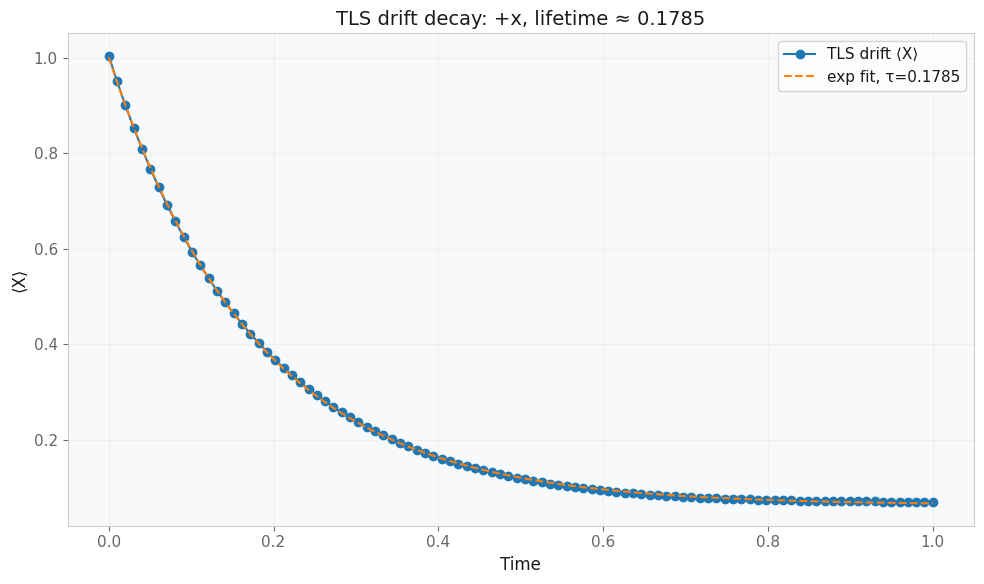

TLS drift (+x) lifetime: 0.1785
Saved plot to: Figures/Plots/notebook_tls_drift_+x_T1.0.png


In [50]:
tls_data_x = {
    "initial_state": "+x",
    "Hilbert_space_large": 15,
    "Hilbert_space_cutted_for_solution": 5,
    "knobs": [1.0, 0.0, 4.0, 0.0],
    "kappa_a": 1.0,
    "kappa_b": 10.0,
    "drift_params": [0.05, 0.15, 0.0],
    "tls_dim": 2,
}

halflife, plot_path, tls_result_x = run_tls_drift_lifetime(tls_data_x, driftH)

### TLS drift - +z state

Hamiltonian:

$H = g_2^* a^{\dagger 2} b + g_2 a^2 b^\dagger - \epsilon_d b^\dagger - \epsilon_d^* b + g_{\rm tls}(t) (a\sigma_+ + a^\dagger\sigma_-)$, with $g_{\rm tls}(t) = A \sin(\omega t + \phi)$ as written in `build_tls_drift`.

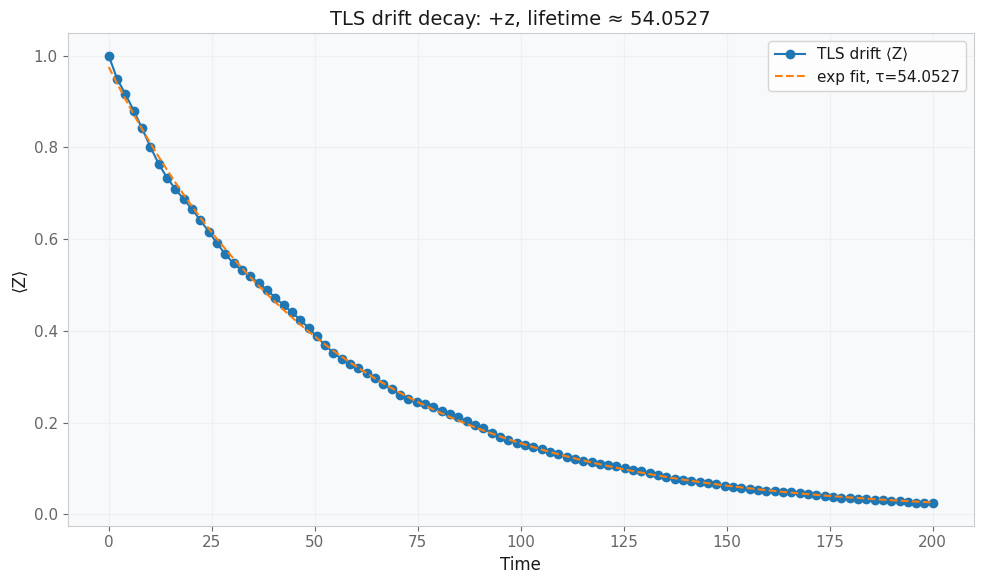

TLS drift (+z) lifetime: 54.0527
Saved plot to: Figures/Plots/notebook_tls_drift_+z_T200.0.png


In [51]:
tls_data_z = {
    "initial_state": "+z",
    "Hilbert_space_large": 15,
    "Hilbert_space_cutted_for_solution": 5,
    "knobs": [1.0, 0.0, 4.0, 0.0],
    "kappa_a": 1.0,
    "kappa_b": 10.0,
    "drift_params": [0.1, 0.15, 0.0],
    "tls_dim": 2,
}

halflife, plot_path, tls_result_z = run_tls_drift_lifetime(tls_data_z, driftH)

## 3. Static Hamiltonians

These examples also use the $+x$ initial state only. Each case shows the Hamiltonian in markdown and displays the saved plot and Wigner GIF.

### Standard static
**Hamiltonian (standard cat):**

$$
H = g_2^*\, a^{\dagger 2} b + g_2\, a^2 b^{\dagger} - \epsilon_d\, b^{\dagger} - \epsilon_d^*\, b
$$

- knobs mapping: `knobs = [g2_re, g2_im, eps_d_re, eps_d_im]`.
- No explicit time dependence (static drive).

### Standard static - +x state


/home/user/miniconda3/envs/qhack26/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIAQArray` has been converted to a `DenseQArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/user/miniconda3/envs/qhack26/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIAQArray` has been converted to a `DenseQArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/user/projects/QHack26/Iason/src/Wigner_function_plotting.py:125: ComplexWarning: Casting complex values to real discards the imaginary part
  values = np.asarray(wigner_data, dtype=float)


Wigner GIF created: wigner.gif


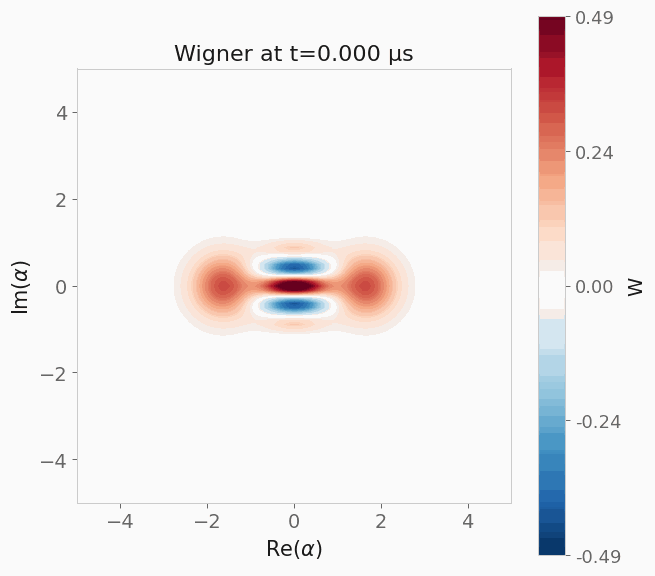

Standard static (+x) lifetime: 0.1785


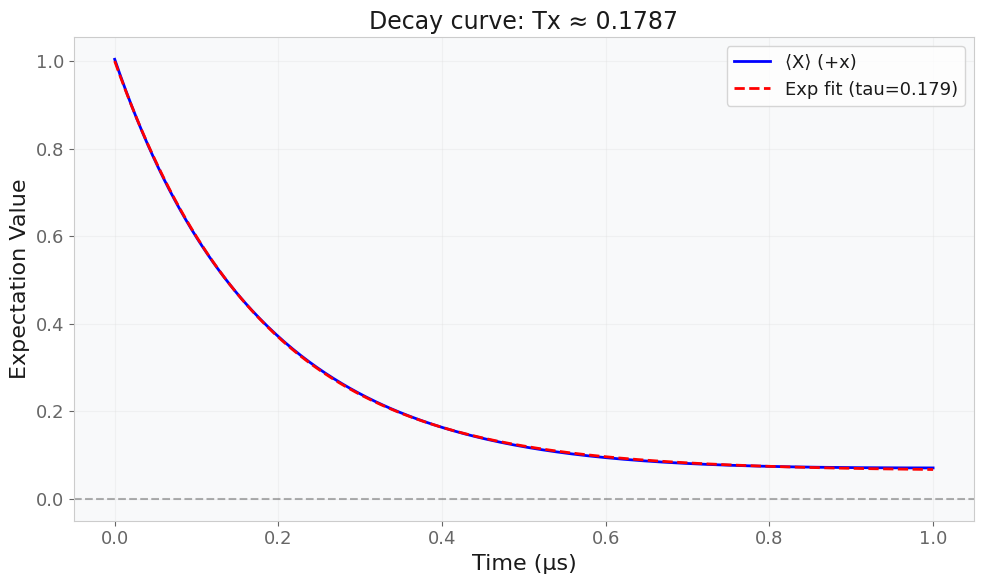

In [33]:
std_data_x = {
    "initial_state": "+x",
    "Hilbert_space_large": 16,
    "Hilbert_space_cutted_for_solution": 5,
    "knobs": [1.0, 0.0, 4.0, 0.0],
    "kappa_a": 1.0,
    "kappa_b": 10.0,
    # tfinal will be assigned below based on initial_state to match generators
}
H = statH.build_standard_cat(std_data_x)
std_data_x["Hamiltonian"] = H
# choose tfinal consistent with generator scripts
tfinal = 200.0 if std_data_x["initial_state"] == "+z" else 1.0
std_data_x["tfinal"] = tfinal
halflife, plot_path, _ = PlotExp.plot_expectation_value(std_data_x)
wigner_path = Wrep.show_wigner_evolution(std_data_x)
print(f"Standard static (+x) lifetime: {halflife:.4f}")

### Standard static - +z state

/home/user/projects/QHack26/Iason/src/Wigner_function_plotting.py:125: ComplexWarning: Casting complex values to real discards the imaginary part
  values = np.asarray(wigner_data, dtype=float)


Wigner GIF created: wigner.gif


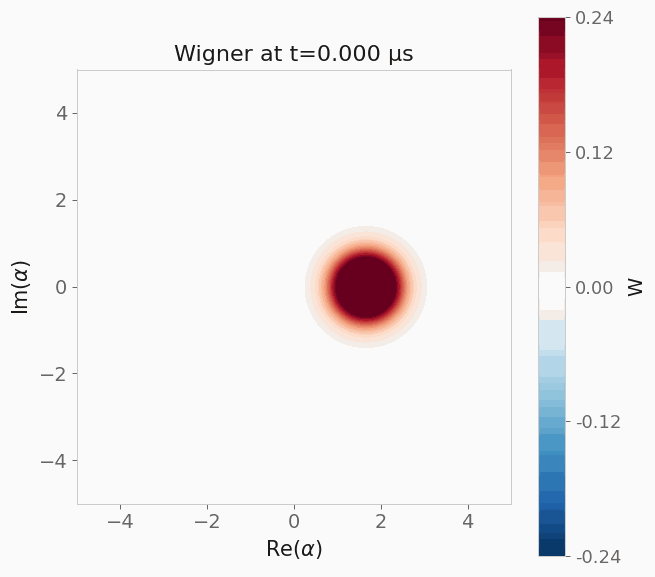

Standard static (+z) lifetime: 57.2711


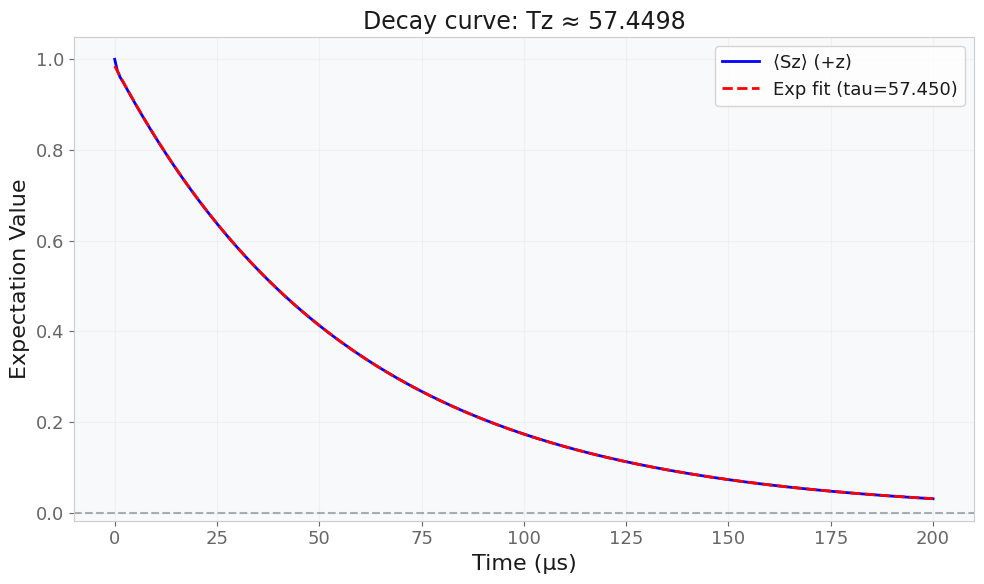

In [34]:
std_data_z = {
    "initial_state": "+z",
    "Hilbert_space_large": 16,
    "Hilbert_space_cutted_for_solution": 5,
    "knobs": [1.0, 0.0, 4.0, 0.0],
    "kappa_a": 1.0,
    "kappa_b": 10.0,
    # tfinal will be assigned below based on initial_state to match generators
}
H = statH.build_standard_cat(std_data_z)
std_data_z["Hamiltonian"] = H
# choose tfinal consistent with generator scripts
tfinal = 200.0 if std_data_z["initial_state"] == "+z" else 1.0
std_data_z["tfinal"] = tfinal
halflife, plot_path, _ = PlotExp.plot_expectation_value(std_data_z)
wigner_path = Wrep.show_wigner_evolution(std_data_z)
print(f"Standard static (+z) lifetime: {halflife:.4f}")

### Kerr static

**Hamiltonian (Kerr cat):**

$$
H = g_2^*\, a^{\dagger 2} b + g_2\, a^2 b^{\dagger} - \epsilon_d\, b^{\dagger} - \epsilon_d^*\, b + K\, (a^{\dagger}a)^2
$$

- The term $K\,(a^{\dagger}a)^2$ is the Kerr nonlinearity; set via `kerr` in `kerr_static_data_*`.

### Kerr static - +x state

/home/user/miniconda3/envs/qhack26/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIAQArray` has been converted to a `DenseQArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/user/miniconda3/envs/qhack26/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIAQArray` has been converted to a `DenseQArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/user/projects/QHack26/Iason/src/Wigner_function_plotting.py:125: ComplexWarning: Casting complex values to real discards the imaginary part
  values = np.asarray(wigner_data, dtype=float)


Wigner GIF created: wigner.gif


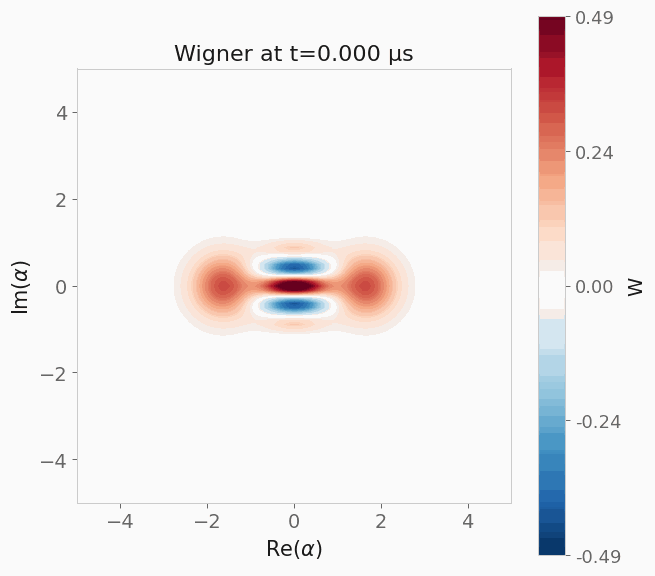

Kerr static (+x) lifetime: 0.1760


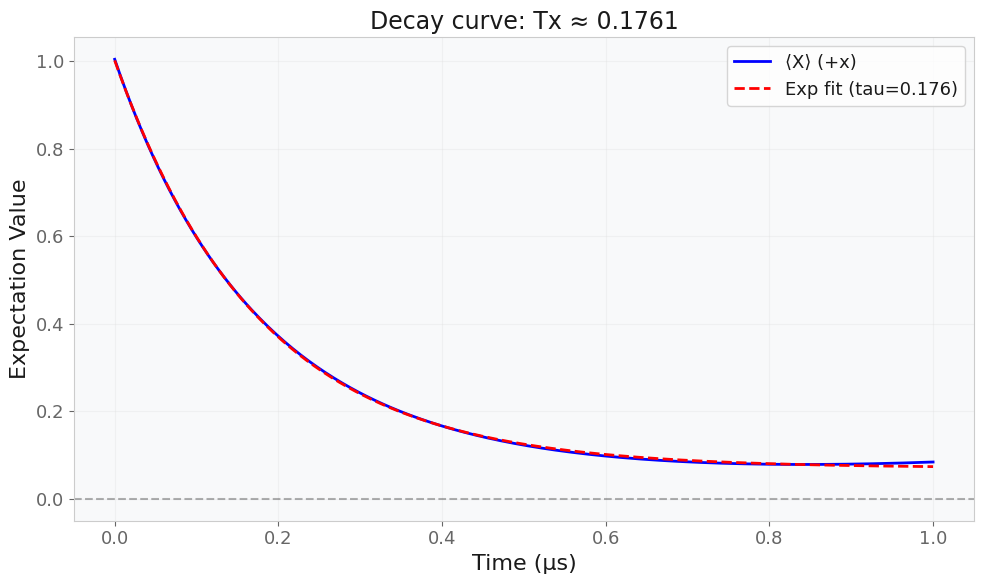

In [35]:
kerr_static_data_x = {
    "initial_state": "+x",
    "Hilbert_space_large": 16,
    "Hilbert_space_cutted_for_solution": 5,
    "knobs": [1.0, 0.0, 4.0, 0.0, 0.2, 0.0],
    "kappa_a": 1.0,
    "kappa_b": 10.0,
    # tfinal will be assigned below based on initial_state to match generators
    "kerr": 0.2,
}
H = statH.build_kerr_cat(kerr_static_data_x)
kerr_static_data_x["Hamiltonian"] = H
# choose tfinal consistent with generator scripts
tfinal = 200.0 if kerr_static_data_x["initial_state"] == "+z" else 1.0
kerr_static_data_x["tfinal"] = tfinal
halflife, plot_path, _ = PlotExp.plot_expectation_value(kerr_static_data_x)
wigner_path = Wrep.show_wigner_evolution(kerr_static_data_x)
print(f"Kerr static (+x) lifetime: {halflife:.4f}")

### Kerr static - +z state

/home/user/projects/QHack26/Iason/src/Wigner_function_plotting.py:125: ComplexWarning: Casting complex values to real discards the imaginary part
  values = np.asarray(wigner_data, dtype=float)


Wigner GIF created: wigner.gif


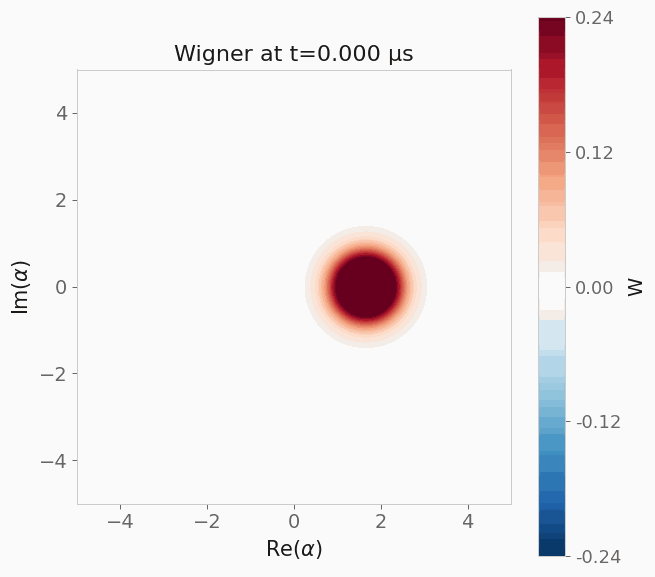

Kerr static (+z) lifetime: 23.2373


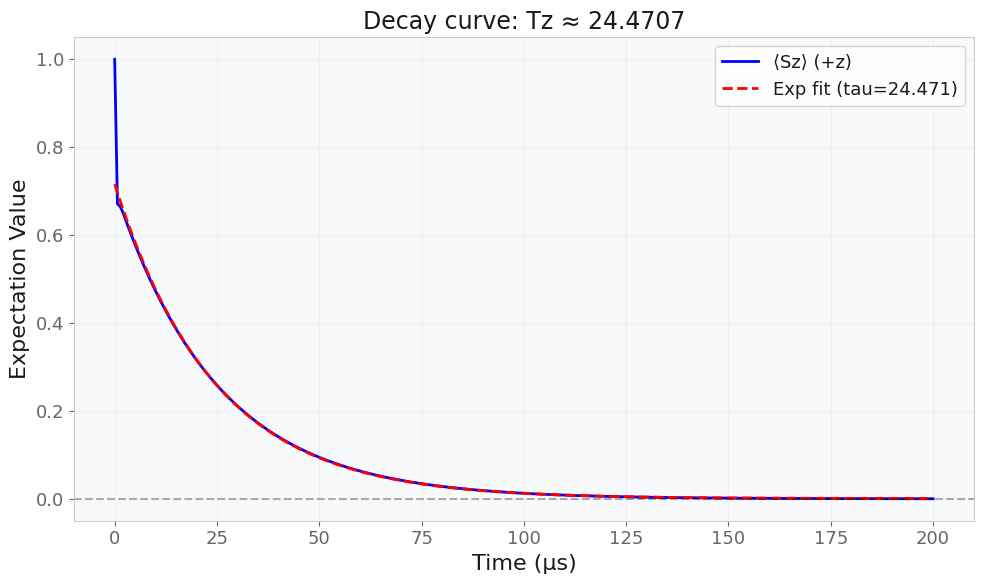

In [36]:
kerr_static_data_z = {
    "initial_state": "+z",
    "Hilbert_space_large": 16,
    "Hilbert_space_cutted_for_solution": 5,
    "knobs": [1.0, 0.0, 4.0, 0.0, 0.2, 0.0],
    "kappa_a": 1.0,
    "kappa_b": 10.0,
    # tfinal will be assigned below based on initial_state to match generators
    "kerr": 0.2,
}
H = statH.build_kerr_cat(kerr_static_data_z)
kerr_static_data_z["Hamiltonian"] = H
# choose tfinal consistent with generator scripts
tfinal = 200.0 if kerr_static_data_z["initial_state"] == "+z" else 1.0
kerr_static_data_z["tfinal"] = tfinal
halflife, plot_path, _ = PlotExp.plot_expectation_value(kerr_static_data_z)
wigner_path = Wrep.show_wigner_evolution(kerr_static_data_z)
print(f"Kerr static (+z) lifetime: {halflife:.4f}")

### Moon cat - +x state

**Hamiltonian (moon cat):**

$$
H = g_2^*\, a^{\dagger 2} b + g_2\, a^2 b^{\dagger} - \epsilon_d\, b^{\dagger} - \epsilon_d^*\, b
+ g_2\, \lambda\, (a^{\dagger}a - \alpha_{\rm moon}^2)\, b + g_2^*\, \lambda^*\, (a^{\dagger}a - (\alpha_{\rm moon}^*)^2)\, b^{\dagger}
$$

- knobs mapping: `knobs = [g2_re, g2_im, eps_d_re, eps_d_im, lam_re, lam_im]`.
- `alpha_moon` may be complex; the conjugate appears in the Hermitian partner term (`(\alpha_{\rm moon}^*)^2`).
- `alpha_moon` controls the moon shift (`data["alpha_moon"]`).

### Moon cat - +x state

**Hamiltonian (moon cat):**

- Builds on the standard cat Hamiltonian with additional parameters `lam` and `alpha_moon` that modify the potential/knobs used to create the moon-shaped superposition.

In code this is created by `statH.build_moon_cat(data)`; conceptually it is the standard cat terms plus extra static terms controlled by `lam`/`alpha_moon` (see implementation for exact form).

Moon cat with alpha_moon=0.0 (+x)


/home/user/miniconda3/envs/qhack26/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIAQArray` has been converted to a `DenseQArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/user/projects/QHack26/Iason/src/Wigner_function_plotting.py:125: ComplexWarning: Casting complex values to real discards the imaginary part
  values = np.asarray(wigner_data, dtype=float)


Wigner GIF created: wigner.gif


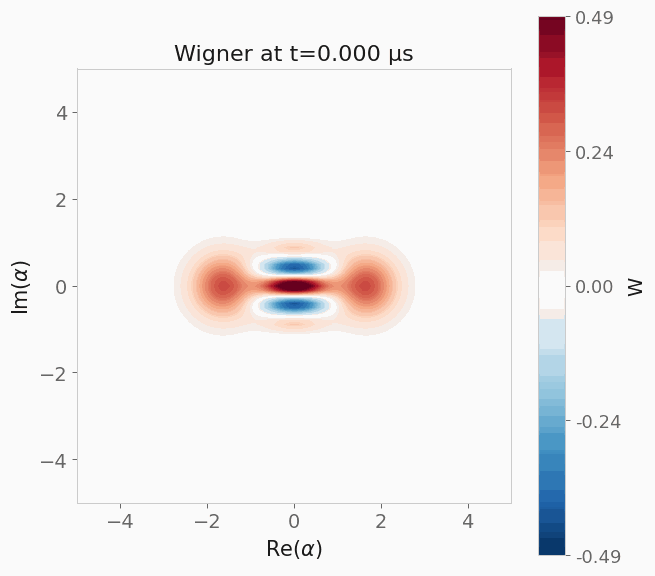

Moon static lifetime (alpha=0.0, +x): 0.1826


NotImplementedError: Adding a scalar to a qarray with the `+` operator is not supported. To add a scaled identity matrix, use `x + scalar * dq.eye_like(x)`. To add a scalar, use `x.addscalar(scalar)`.

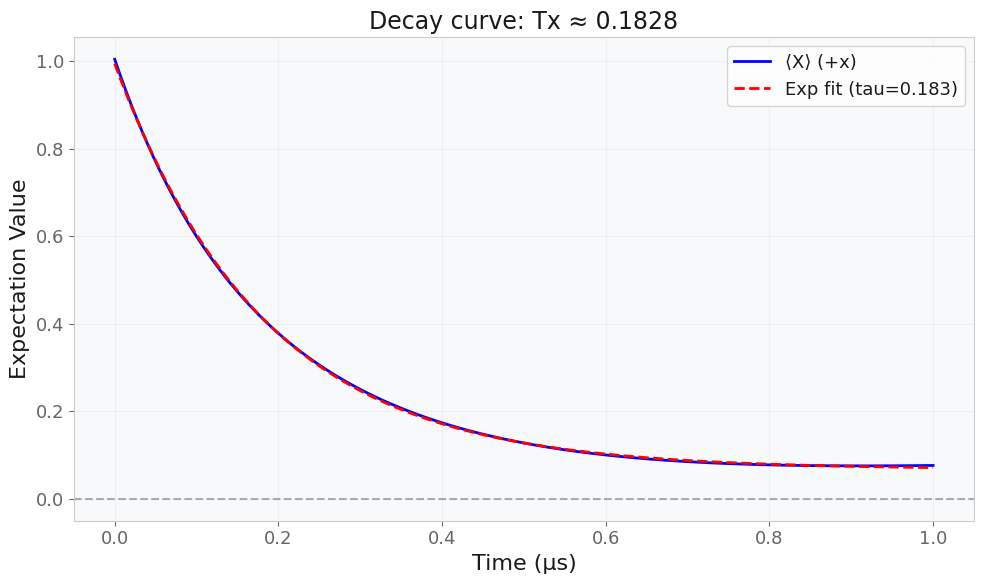

In [37]:
for alpha_moon in [0.0, 2.0]:
    moon_data_x = {
        "initial_state": "+x",
        "Hilbert_space_large": 16,
        "Hilbert_space_cutted_for_solution": 5,
        "knobs": [1.0, 0.0, 4.0, 0.0, 0.6, 0.0],
        "kappa_a": 1.0,
        "kappa_b": 10.0,
        # tfinal will be assigned below based on initial_state to match generators
        "lam": 0.6,
        "alpha_moon": alpha_moon,
    }
    H = statH.build_moon_cat(moon_data_x)
    moon_data_x["Hamiltonian"] = H
    print(f"Moon cat with alpha_moon={alpha_moon} (+x)")
    tfinal = 200.0 if moon_data_x["initial_state"] == "+z" else 1.0
    moon_data_x["tfinal"] = tfinal
    halflife, plot_path, _ = PlotExp.plot_expectation_value(moon_data_x)
    wigner_path = Wrep.show_wigner_evolution(moon_data_x)
    print(f"Moon static lifetime (alpha={alpha_moon}, +x): {halflife:.4f}")

### Moon cat - +z state

Moon cat with alpha_moon=0.0 (+z)


/home/user/projects/QHack26/Iason/src/Wigner_function_plotting.py:125: ComplexWarning: Casting complex values to real discards the imaginary part
  values = np.asarray(wigner_data, dtype=float)


Wigner GIF created: wigner.gif


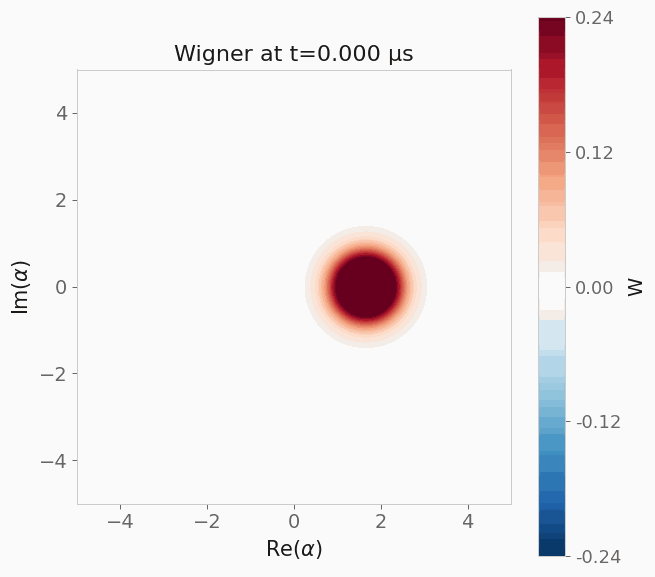

Moon static lifetime (alpha=0.0, +z): 29.5313


NotImplementedError: Adding a scalar to a qarray with the `+` operator is not supported. To add a scaled identity matrix, use `x + scalar * dq.eye_like(x)`. To add a scalar, use `x.addscalar(scalar)`.

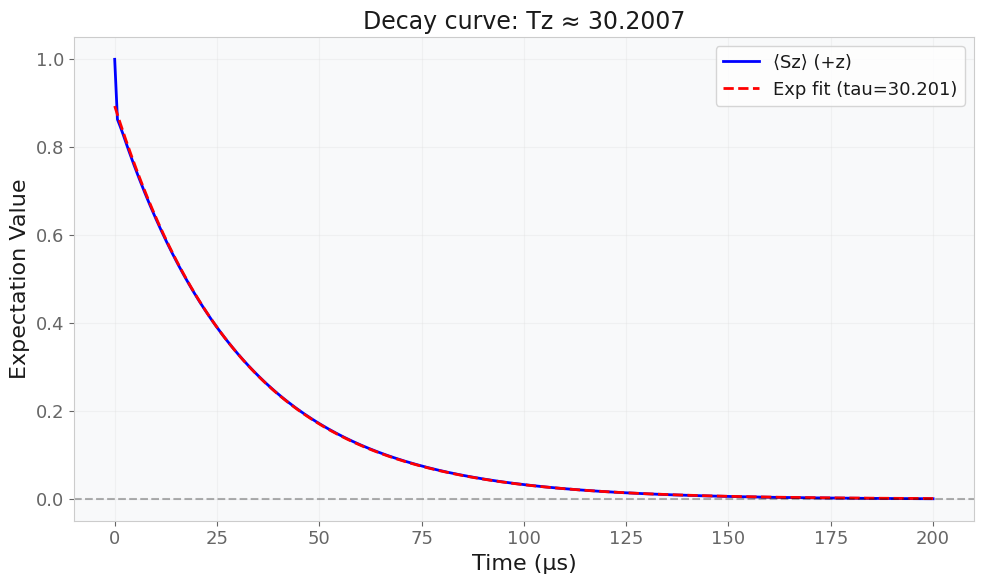

In [38]:
for alpha_moon in [0.0, 2.0]:
    moon_data_z = {
        "initial_state": "+z",
        "Hilbert_space_large": 16,
        "Hilbert_space_cutted_for_solution": 5,
        "knobs": [1.0, 0.0, 4.0, 0.0, 0.6, 0.0],
        "kappa_a": 1.0,
        "kappa_b": 10.0,
        # tfinal will be assigned below based on initial_state to match generators
        "lam": 0.6,
        "alpha_moon": alpha_moon,
    }
    H = statH.build_moon_cat(moon_data_z)
    moon_data_z["Hamiltonian"] = H
    print(f"Moon cat with alpha_moon={alpha_moon} (+z)")
    tfinal = 200.0 if moon_data_z["initial_state"] == "+z" else 1.0
    moon_data_z["tfinal"] = tfinal
    halflife, plot_path, _ = PlotExp.plot_expectation_value(moon_data_z)
    wigner_path = Wrep.show_wigner_evolution(moon_data_z)
    print(f"Moon static lifetime (alpha={alpha_moon}, +z): {halflife:.4f}")

### Cross-Kerr - +x state

### Cross-Kerr - +x state

**Hamiltonian (cross-Kerr coupling):**

$$
H = H_{\rm cat} + \chi\, a^{\dagger}a\, b^{\dagger}b
$$

- Here $H_{\rm cat}$ denotes the standard cat terms (drive + two-photon terms); `chi` sets the cross-Kerr strength.

Cross-Kerr Hamiltonian (+x)


/home/user/miniconda3/envs/qhack26/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIAQArray` has been converted to a `DenseQArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/user/projects/QHack26/Iason/src/Wigner_function_plotting.py:125: ComplexWarning: Casting complex values to real discards the imaginary part
  values = np.asarray(wigner_data, dtype=float)


Wigner GIF created: wigner.gif


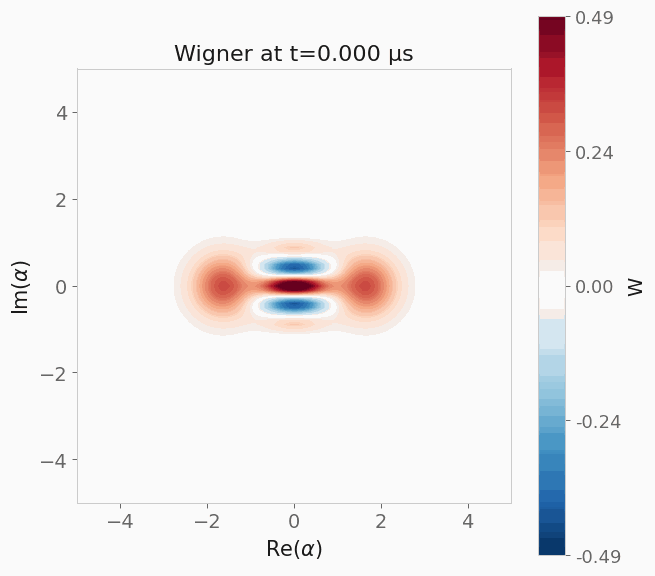

Cross-Kerr lifetime (+x): 0.1785


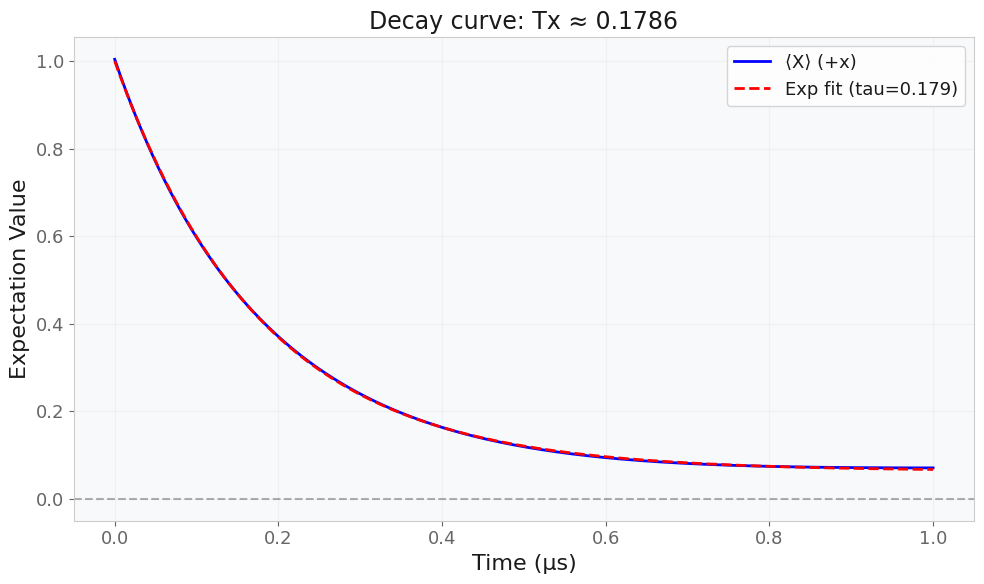

In [39]:
cross_data_x = {
    "initial_state": "+x",
    "Hilbert_space_large": 16,
    "Hilbert_space_cutted_for_solution": 5,
    "knobs": [1.0, 0.0, 4.0, 0.0, 0.2, 0.0],
    "kappa_a": 1.0,
    "kappa_b": 10.0,
    # tfinal will be assigned below based on initial_state to match generators
    "chi": 0.2,
}
H = statH.build_cross_kerr(cross_data_x)
cross_data_x["Hamiltonian"] = H
print("Cross-Kerr Hamiltonian (+x)")
tfinal = 200.0 if cross_data_x["initial_state"] == "+z" else 1.0
cross_data_x["tfinal"] = tfinal
halflife, plot_path, _ = PlotExp.plot_expectation_value(cross_data_x)
wigner_path = Wrep.show_wigner_evolution(cross_data_x)
print(f"Cross-Kerr lifetime (+x): {halflife:.4f}")

### Cross-Kerr - +z state

Cross-Kerr Hamiltonian (+z)


/home/user/projects/QHack26/Iason/src/Wigner_function_plotting.py:125: ComplexWarning: Casting complex values to real discards the imaginary part
  values = np.asarray(wigner_data, dtype=float)


Wigner GIF created: wigner.gif


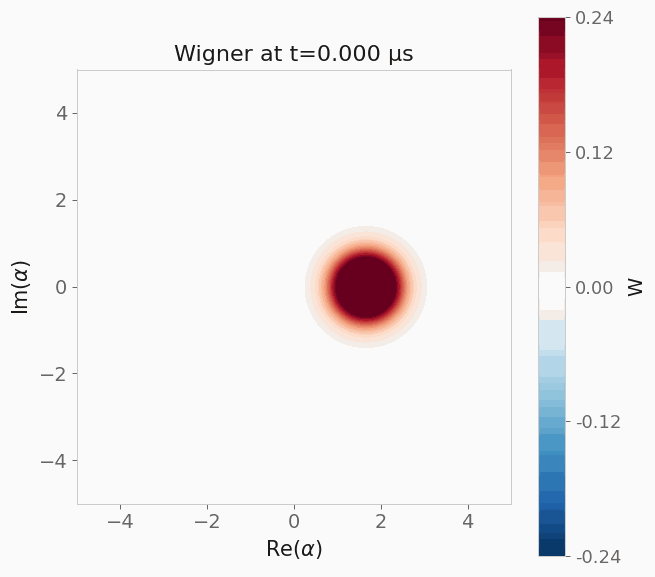

Cross-Kerr lifetime (+z): 57.0089


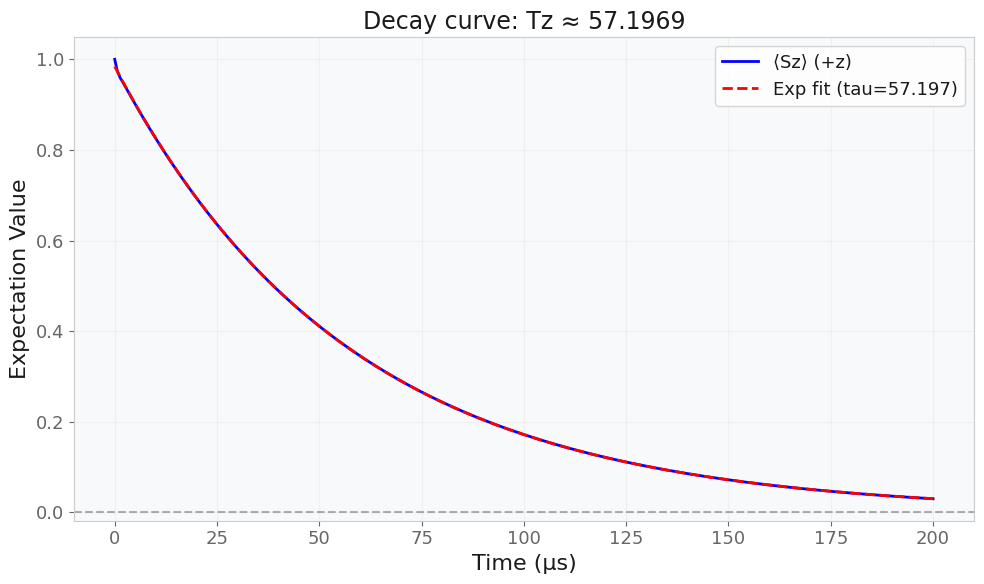

In [40]:
cross_data_z = {
    "initial_state": "+z",
    "Hilbert_space_large": 16,
    "Hilbert_space_cutted_for_solution": 5,
    "knobs": [1.0, 0.0, 4.0, 0.0, 0.2, 0.0],
    "kappa_a": 1.0,
    "kappa_b": 10.0,
    # tfinal will be assigned below based on initial_state to match generators
    "chi": 0.2,
}
H = statH.build_cross_kerr(cross_data_z)
cross_data_z["Hamiltonian"] = H
print("Cross-Kerr Hamiltonian (+z)")
tfinal = 200.0 if cross_data_z["initial_state"] == "+z" else 1.0
cross_data_z["tfinal"] = tfinal
halflife, plot_path, _ = PlotExp.plot_expectation_value(cross_data_z)
wigner_path = Wrep.show_wigner_evolution(cross_data_z)
print(f"Cross-Kerr lifetime (+z): {halflife:.4f}")